# Music Recommendation Algorithm - Initial EDA

Author: Nick Peril  
Project: TKH Technology Fellowship Portfolio Project   
Dataset: train.csv (available in data folder)

### Objectives:
The goal of this EDA is to identify what the dataset look like, and what patterns can be discovered before modeling.

---

### Importing libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

### Loading my dataset:

In [2]:
df = pd.read_csv('/Users/saadult/music-reco/data/raw_data/train.csv')

---

### Initial dataset inspection:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

*The dataset contains a total of 24 columns and 28,362 rows. Interestingly, the very first column named `Unnamed: 0` contains integer values that seem to be old index values and potentially has no meaning and do not describe the songs themselves. I need to decide later on how I should treat this column.* 

In [4]:
df.head(10)

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0
5,14,perry como,round and round (with mitchell ayres and his o...,1950,pop,convoy light dead ahead merchantmen trump dies...,98,0.001053,0.420685,0.001053,0.074078,0.001053,0.001053,0.001053,0.001053,0.001053,0.001053,0.001053,0.172173,0.001053,0.128292,0.001053,violence,1.0
6,15,freestyle,opm medley: when i met you,1950,pop,piece mindin world knowin life come bring give...,179,0.000483,0.000483,0.371817,0.040712,0.000483,0.000483,0.000483,0.384703,0.000483,0.000483,0.000483,0.044355,0.000483,0.000483,0.123150,world/life,1.0
7,17,johnny mathis,it's not for me to say,1950,pop,care moment hold fast press lips dream heaven ...,21,0.002506,0.002506,0.336056,0.002506,0.002506,0.002506,0.176861,0.002506,0.002506,0.002506,0.002506,0.386887,0.002506,0.062602,0.002506,world/life,1.0
8,20,stélios kazantzídis,klapse me mana klapse me,1950,pop,lonely night surround power read mind hour nig...,30,0.083537,0.002024,0.002024,0.248273,0.002024,0.002024,0.401801,0.167783,0.002024,0.002024,0.002024,0.002024,0.002024,0.002024,0.031600,romantic,1.0
9,23,stélios kazantzídis,finito la mouzika,1950,pop,tear heart seat stay awhile tear heart game st...,61,0.001120,0.102548,0.001120,0.053944,0.001120,0.001120,0.001120,0.091572,0.001120,0.001120,0.105752,0.001120,0.001120,0.630507,0.001120,sadness,1.0


---

#### <u>Understanding the dataset features/columns</u>:
* `artist_name`: The name of the artist 
* `track_name`: The name of the song 
* `release_date`: When this song was released 
* `genre`: The categorical genre of this song
* `lyrics`: The pre-tokenized lyrics of this song. *Disclaimer: note that as this is real-world data, lyrical content is often obscene.* 
* `len`: The number of words in the lyrics of this song 
* `dating`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with dating. 
* `violence`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with violence. 
* `world/life`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the world or life in general terms. 
* `night/time`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do night-life or time. 
* `shake the audience`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with provocative feeling. 
* `family/gospel`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with family-oriented content or the gospel. 
* `romantic`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with romantic feeling. 
* `communication`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with communication (either in romantic terms or otherwise). 
* `obscene`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with obscene content (money, rockstar-lifestyle, etc). 
* `music`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with music (music about music, basically). 
* `movement/places`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with movement or various locations. 
* `light/visual perceptions`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the sun or other physical weather-related patterns. 
* `family/spiritual`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the importance of family or spirituality.
* `sadness`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with the importance of family or spirituality. 
* `feelings`: A score from 0 to 1 expressing how likely it is that this song’s lyrics have something to do with emotions, either positive or negative. 
* `topic`: The categorical label of lyrical content 
* `age`: A score from 0 to 1 expressing how “old” a song is from our perspective. 1 being the oldest, and 0 being the newest.

---

### Missing values:

In [7]:
df.isnull().sum()

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64

<u>Insight:</u> *There are no missing values in any of the columns. This means the dataset is complete and no need for filling or dropping missing values.*

### Duplicate values:

In [8]:
df.duplicated().sum()

np.int64(0)

<u>Insight:</u> *There are no duplicate values in the dataset.*

---

### Descriptive Statistics of the dataset:

In [6]:
df.describe().round(2)

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00,28362.00
mean,42948.17,1990.24,73.03,0.02,0.12,0.12,0.06,0.02,0.02,0.05,0.08,0.10,0.06,0.05,0.05,0.02,0.13,0.03,0.43
std,24747.81,18.49,41.83,0.05,0.18,0.17,0.11,0.04,0.04,0.11,0.11,0.18,0.12,0.09,0.09,0.05,0.18,0.07,0.26
min,0.00,1950.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
25%,20393.50,1975.00,42.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.19
50%,45407.00,1991.00,63.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.41
75%,64089.50,2007.00,93.00,0.00,0.19,0.20,0.07,0.01,0.00,0.04,0.13,0.09,0.06,0.05,0.06,0.03,0.24,0.03,0.64
max,82451.00,2019.00,199.00,0.65,0.98,0.96,0.97,0.50,0.55,0.94,0.65,0.99,0.96,0.64,0.67,0.62,0.98,0.96,1.00


<u>Insights:</u>
* The dataset has 28,362 songs with release years ranging from 1950 to 2019. The average release year is around 1990, so the dataset includes a good mix of older and more recent songs.
* The lyric length varies a lot. Some songs have very short lyrics, while others are much longer. This is something that need to be considered later because longer songs could have more words and possibly stronger or more varied topic scores.
* Most of the topic-related columns have low average values, which tells that the songs usually do not strongly belong to just one topic. However, topics like sadness, violence, world/life, and obscene have slightly higher averages compared to the other themes. This could mean that these topics appear more often in the lyrics.
* Several topic columns have maximum values close to 1.00. This means some songs are strongly connected to a specific theme, which could be useful later when grouping similar songs together or building a recommendation system.
* Overall, the dataset looks clean and ready for more exploration. Since the topic scores and lyric length vary quite a bit, there's a need to be careful with feature selection and scaling before using unsupervised machine learning models.

---

### **Univariate Analysis**

#### <u>Genre Distribution:</u>
The genre distribution shows which music categories dominate the dataset. This matters because clusters may be influenced by overrepresented genres.

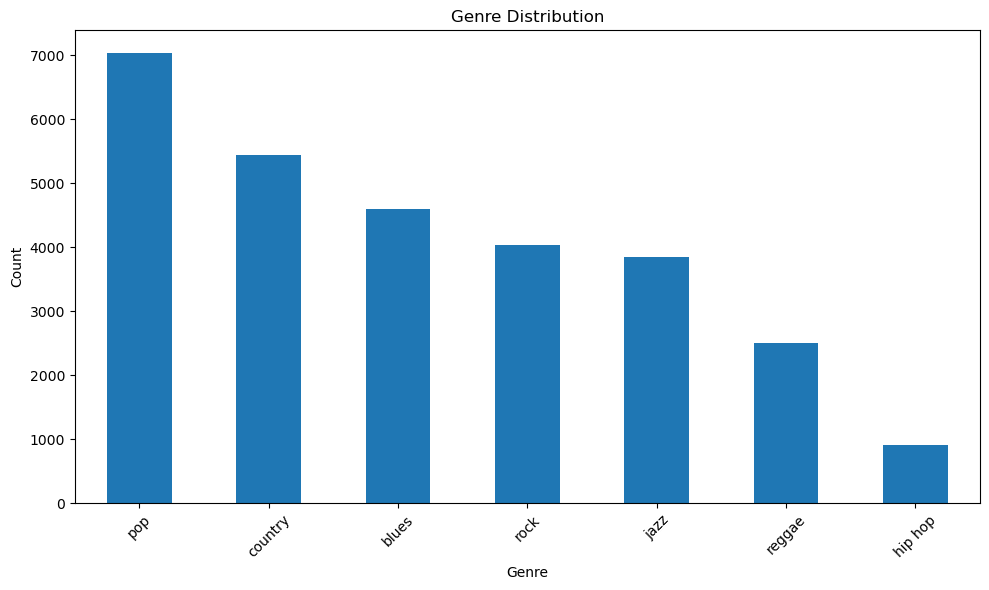

In [ ]:
# Setting the size of the chart
plt.figure(figsize=(10, 6))

# Counting each genre and creating a bar chart
df["genre"].value_counts().plot(kind="bar")

# Adding title and labels to the chart
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")

# Rotateing genre labels so they are easier to read
plt.xticks(rotation=45)
# Adjusting spacing so labels and titles fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/genre_distribution.png")

# Displaying the chart
plt.show()

<u>Insights:</u>
* **Pop is the most represented genre** in the dataset, with the highest number of songs compared to the other genres.
* **Country, blues, rock, and jazz also have strong representation**, but their counts are still noticeably lower than pop.
* **The dataset is not evenly distributed across genres**. Some genres have many more songs than others, while genres like hip hop and reggae have much smaller counts.
* **Hip hop has the lowest number of songs** in the dataset, which means it may have less influence when building clusters or recommendations.
* This **genre imbalance is important to keep in mind** because the unsupervised machine learning model may learn stronger patterns from genres with more songs, such as pop and country.

---

#### <u>Topic Distribution:</u>
Topic distribution helps us understand the dominant lyrical themes in the dataset.

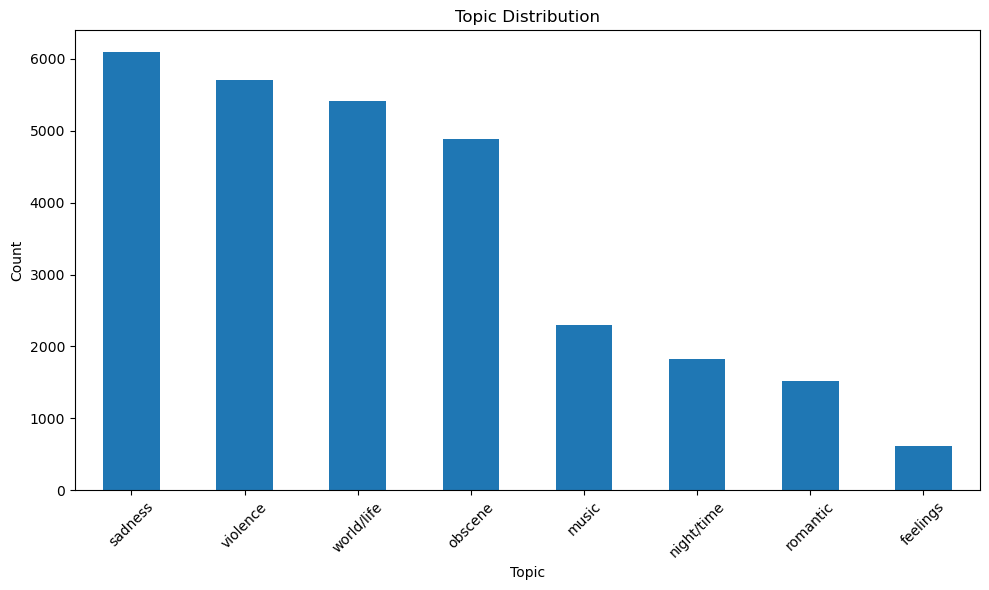

In [15]:
# Setting the size of the chart
plt.figure(figsize=(10, 6))

# Counting each topic and creating a bar chart
df["topic"].value_counts().plot(kind="bar")

# Adding a title and labels to the chart
plt.title("Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Count")

# Rotating topic labels so they are easier to read
plt.xticks(rotation=45)
# Adjusting spacing so labels and titles fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/topic_distribution.png")

# Displays the chart
plt.show()

<u>Insights:</u>
* **Sadness is the most common topic** in the dataset, meaning many songs are strongly connected to emotional or sad themes.
* **Violence, world/life, and obscene are also highly represented**, showing that many songs include themes related to conflict, life experiences, or explicit content.
* **There is a noticeable drop after the top four topics**. Topics like music, night/time, romantic, and feelings have much lower counts compared to sadness, violence, world/life, and obscene.
* **Romantic and feelings are among the least represented topics**, which is interesting because we might expect love or emotions to appear more often in song lyrics.
* **The topic distribution is imbalanced**, so some themes may have a stronger influence on clustering or recommendation results than less common topics.
* **This chart helps show the dominant lyrical themes** in the dataset, which can be useful later when comparing songs based on emotional or thematic similarity.

---

#### <u>Song Length Distribution:</u>
Most songs fall within a certain lyric-length range, while some songs may be unusually long. These extreme values may affect clustering.

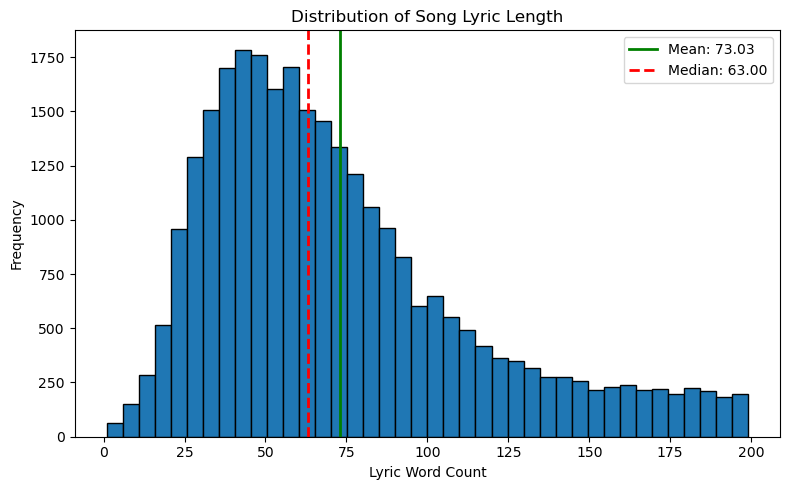

In [19]:
mean_len = df["len"].mean()      # Calculating the average lyric length
median_len = df["len"].median()  # Calculating the median lyric length

# Setting the size of the histogram
plt.figure(figsize=(8, 5))

# Creating a histogram of lyric length using 40 bins
plt.hist(df["len"], bins=40, edgecolor="black")

# Adding a solid green vertical line for the mean
plt.axvline(
    mean_len,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Mean: {mean_len:.2f}"
)

# Adding a red dashed vertical line for the median
plt.axvline(
    median_len,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_len:.2f}"
)

# Displaying the legend for mean and median
plt.legend()

# Adding a title and labels to the chart
plt.title("Distribution of Song Lyric Length")
plt.xlabel("Lyric Word Count")
plt.ylabel("Frequency")

# Adjusting spacing so chart labels fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/song_length_distribution.png")

# Displaying the chart
plt.show()

<u>Insights:</u>
* **Most songs have lyric lengths between around 30 and 90 words**, with the highest concentration around 40–60 words.
* The **mean lyric length is 73 words, while the median is 63 words**, meaning the distribution is slightly right-skewed.
* **Some songs have much longer lyrics**, which pulls the mean higher than the median.
* **Very short and very long songs are less common** compared to songs with medium-length lyrics.
* **This matters for modeling** because lyric length may influence similarity scores, so it may need to be scaled before applying unsupervised machine learning.

---

### **Bivariate Analysis**

#### <u>Average sadness by genre</u>
Analyzing average sadness by genre to see which music genres tend to have stronger sad or emotional lyrical themes. This can guide feature selection and improve how songs are grouped in the unsupervised learning model.

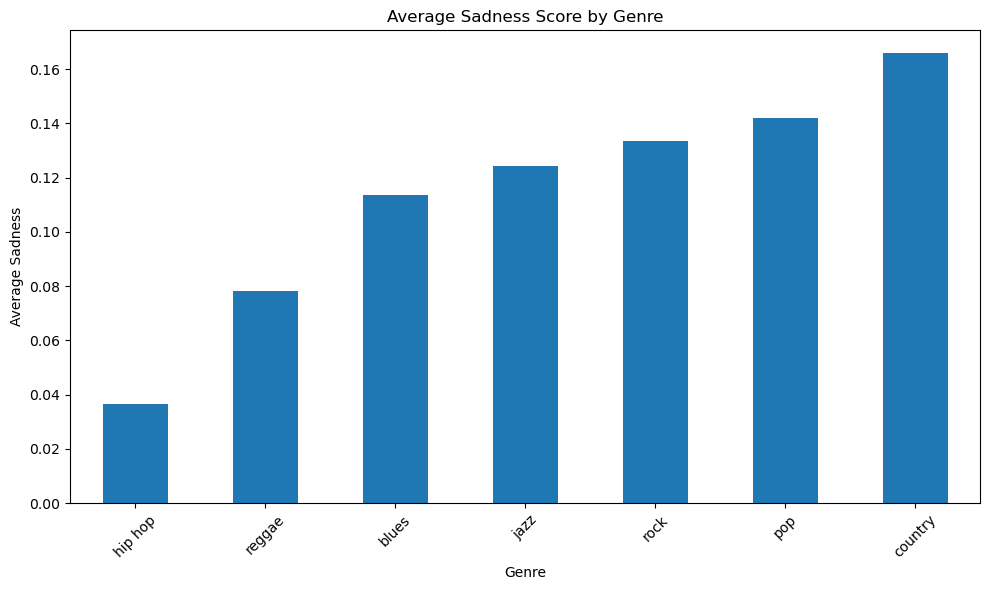

In [20]:
# Setting the size of the chart
plt.figure(figsize=(10, 6))

# Grouping songs by genre, calculating the average sadness score, sorting the values, and plotting them as a bar chart
df.groupby("genre")["sadness"].mean().sort_values().plot(kind="bar")  

# Adding a title and labels to the chart
plt.title("Average Sadness Score by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Sadness")

# Rotating genre labels so they are easier to read
plt.xticks(rotation=45)
# Adjusting spacing so labels and titles fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/avg_sadness_by_genre.png")

# Displaying the chart
plt.show()

<u>Insights:</u>
* **Country has the highest average sadness score**, suggesting that country songs in this dataset tend to have stronger sad or emotional lyrical themes.
* **Pop, rock, and jazz also show relatively high sadness scores**, meaning sadness appears to be a noticeable theme across these genres as well.
* **Hip hop has the lowest average sadness score**, which suggests that sadness is less dominant in hip hop lyrics compared to the other genres in this dataset.
* **There is a clear difference between genres**, showing that sadness is not evenly distributed across all music types.
* **This insight can help with modeling** because genres with similar sadness scores may end up closer together when grouping songs based on lyrical themes.

---

#### <u>Average violence by genre</u>
Analyzing average violence by genre to see which music genres tend to have stronger conflict-related or aggressive lyrical themes. This can guide feature selection and improve how songs are grouped in the unsupervised learning model.

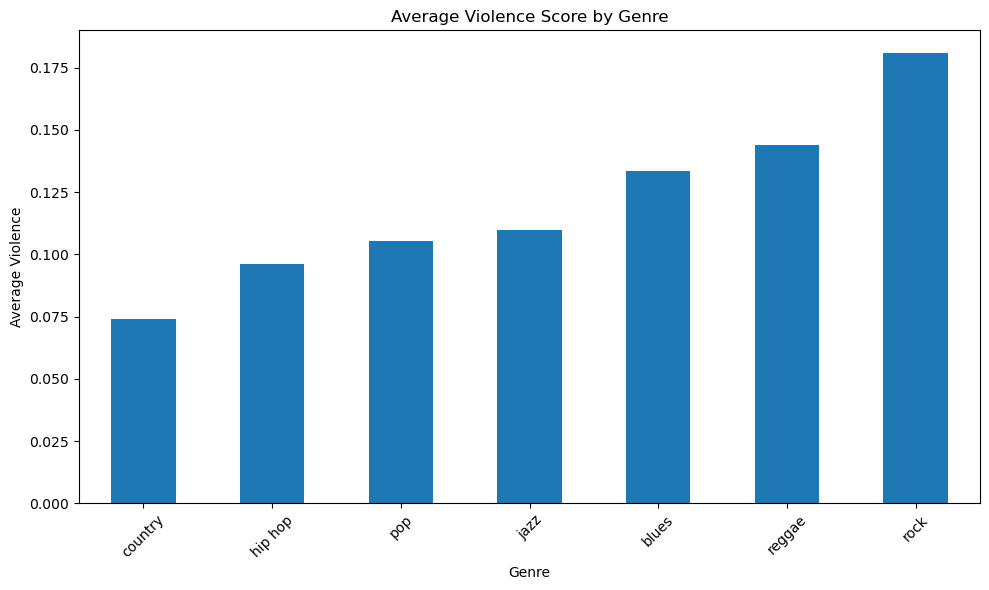

In [21]:
# Setting the size of the chart
plt.figure(figsize=(10, 6))

# Grouping songs by genre, calculating the average violence score, sorting the values, and plotting them as a bar chart
df.groupby("genre")["violence"].mean().sort_values().plot(kind="bar")  

# Adding a title and labels to the chart
plt.title("Average Violence Score by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Violence")

# Rotating genre labels so they are easier to read
plt.xticks(rotation=45)
# Adjusing spacing so labels and titles fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/avg_violence_by_genre.png")

# Displaying the chart
plt.show()

<u>Insights:</u>
* **Rock has the highest average violence score**, suggesting that rock songs in this dataset tend to have stronger conflict-related or intense lyrical themes.
* **Reggae and blues also show relatively high violence scores**, meaning these themes appear more strongly in those genres compared to others.
* **Country has the lowest average violence score**, which suggests that violence-related themes are less common in country songs in this dataset.
* **The scores vary noticeably across genres**, showing that violence is not evenly distributed across all music types.
* **This can help with modeling** because songs or genres with similar violence scores may be grouped closer together when building clusters or recommendations.

---

#### <u>Release date vs. age</u>
`release_date` and `age` are likely strongly related. If they are highly correlated, we probably only need one of them.

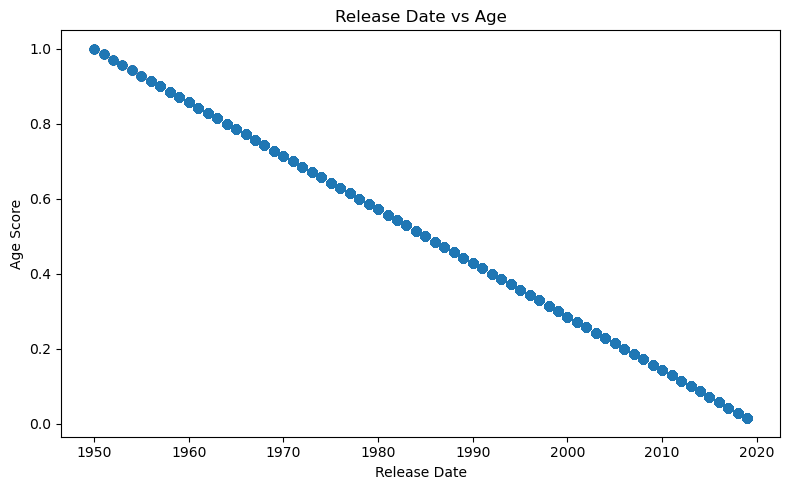

In [23]:
# Setting the size of the scatter plot
plt.figure(figsize=(8, 5))

# Creating a scatter plot comparing release year/date with age score
# alpha=0.3 makes the points more transparent so overlapping points are easier to see
plt.scatter(df["release_date"], df["age"], alpha=0.3)  

# Adding a title to the chart
plt.title("Release Date vs Age")
plt.xlabel("Release Date")
plt.ylabel("Age Score")

# Adjusting spacing so labels and titles fit properly
plt.tight_layout()

# Saving the chart as an image file
plt.savefig("../docs/images/release_date_vs_age.png")

# Displaying the chart
plt.show()

<u>Insights:</u>
* **There is a clear negative relationship between release date and age score**. As the release year gets newer, the age score goes down.
* **Older songs have higher age scores**, with songs from around 1950 close to an age score of 1.0.
* **Newer songs have lower age scores**, with songs closer to 2019 having age scores near 0.
* **The relationship looks almost perfectly linear**, which suggests that the age column was likely created or scaled directly from the release year.
* **This is useful for modeling** because `age` can help the model understand the time period of a song, but it may also be redundant with `release_date` since both carry very similar information.

---

### **Multivariate Analysis**

#### <u>Correlation Heatmap</u>
Creating a correlation heatmap to see how the numeric features relate to each other and identify which variables may be strongly connected before building the model.

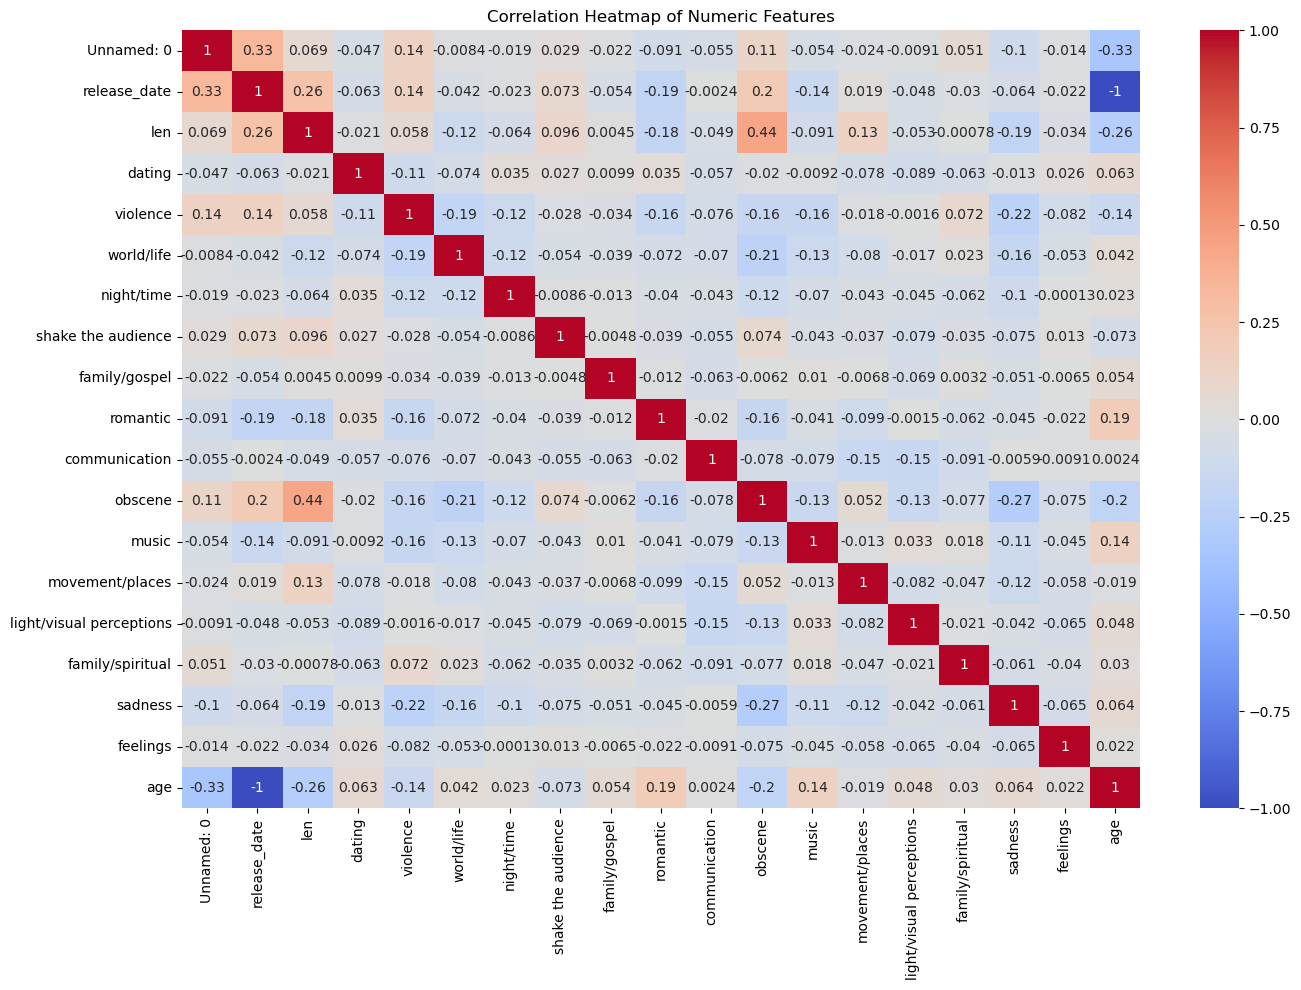

In [25]:
# Selecting only numeric columns from the dataset for correlation analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])  

# Setting the size of the heatmap
plt.figure(figsize=(14, 10))

# Creating a correlation heatmap using the numeric columns
# cmap="coolwarm" showing negative and positive correlations with different colors
# annot=False hiding the correlation numbers to keep the chart cleaner
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)  

# Adding a title to the heatmap
plt.title("Correlation Heatmap of Numeric Features")

# Adjusting spacing so the chart fits properly
plt.tight_layout()

# Saving the heatmap as an image file
plt.savefig("../docs/images/correlation_heatmap.png")

# Displays the heatmap
plt.show()

<u>Insights:</u>
* **`release_date` and `age` have a perfect negative correlation (-1.00)**, meaning they carry almost the same information in opposite directions. I may only need one of these features for modeling.
* **Most topic features have weak correlations with each other**, which suggests that the lyrical themes are mostly independent and not strongly overlapping.
* **`len` has a moderate positive correlation with `obscene` (0.44)**, meaning longer songs may tend to have higher obscene scores in this dataset.
* **`sadness` has a negative relationship with `obscene` (-0.27) and violence (-0.22)**, suggesting that songs with stronger sadness scores may not always overlap with more explicit or violent themes.
* **There are no many extremely strong correlations aside from `release_date` and `age`**, so most features may still provide unique information for clustering or recommendation modeling.

---

#### <u>Pairplot of selected numeric features</u>
Using a pairplot to visually compare relationships between selected numeric features and check for patterns, clusters, or outliers.

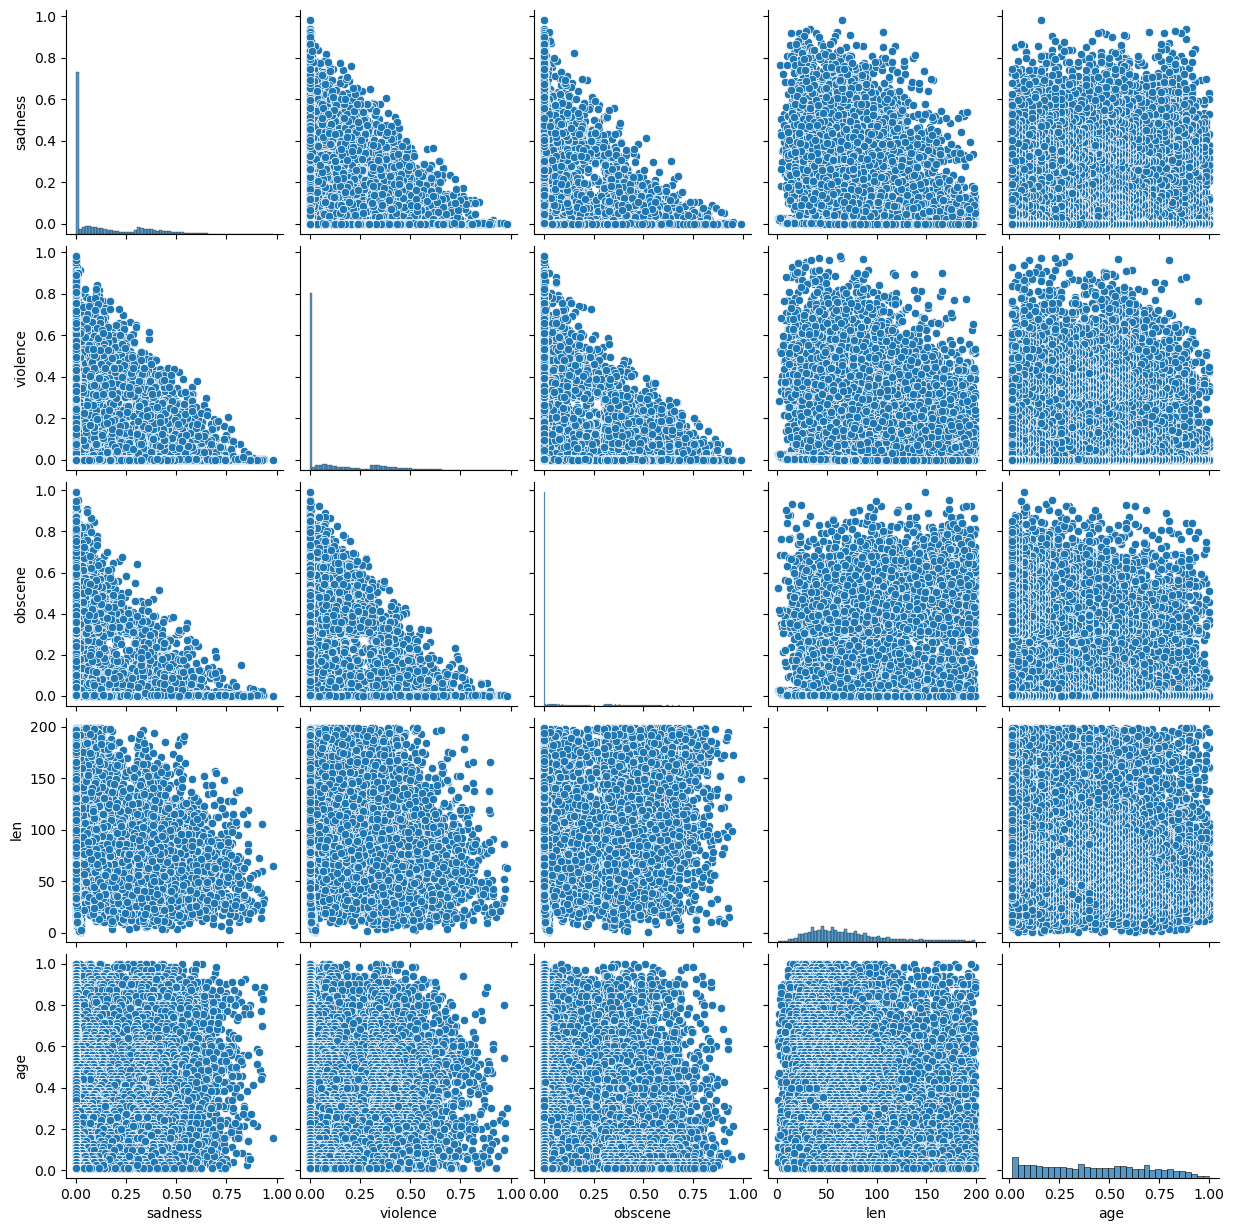

In [26]:
# Selecting a few important numeric features to compare against each other
selected_features = ["sadness", "violence", "obscene", "len", "age"]  

# Creating a pairplot to show relationships and distributions between the selected features
sns.pairplot(df[selected_features])  

# Saving the pairplot as an image file
plt.savefig("../docs/images/pairplot_selected_features.png")  

# Displaying the pairplot
plt.show()

<u>Insights</u>
* **Most topic scores are concentrated near 0**, meaning many songs have low values for sadness, violence, and obscene themes.
* **Sadness, violence, and obscene show some negative-looking relationships with each other**, suggesting that when one topic score is high, the others are often lower.
* **Lyric length does not show a very strong pattern with the topic scores**, but there are some longer songs spread across different sadness, violence, and obscene levels.
* **Age appears widely spread across the topic scores**, meaning both older and newer songs can have different levels of sadness, violence, or obscene content.
* **The pairplot does not show very clear separate clusters yet**, but it helps confirm that these features may still be useful for exploring song similarity before modeling.

---

#### <u>Average topic scores by genre heatmap</u>
Creating a heatmap of average topic scores by genre to compare how different lyrical themes appear across music genres.

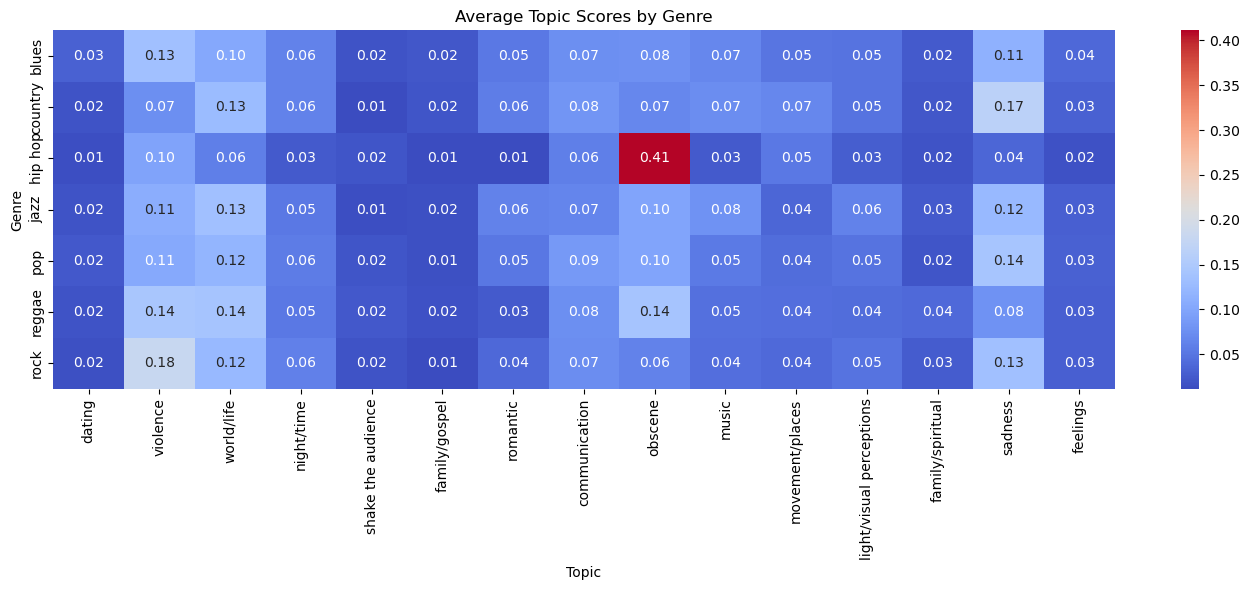

In [31]:
# Selecting the topic-related columns I want to compare across genres
topic_cols = [
    "dating", "violence", "world/life", "night/time", "shake the audience",
    "family/gospel", "romantic", "communication", "obscene", "music",
    "movement/places", "light/visual perceptions", "family/spiritual",
    "sadness", "feelings"
]

# Grouping the dataset by genre and calculate the average score for each topic column
# This helps me understand which topics are more common or stronger within each genre
genre_topic_avg = df.groupby("genre")[topic_cols].mean()

# Setting the figure size to make the heatmap wide enough for all topic labels
plt.figure(figsize=(14, 6))

# Creating a heatmap showing the average topic scores by genre
sns.heatmap(
    genre_topic_avg, 
    cmap="coolwarm",        # uses color intensity to show low vs high values
    annot=True,             # displays the actual average values inside each cell
    fmt=".2f"               # rounds the displayed values to 2 decimal places
)

# Adding a clear title and axis labels for readability
plt.title("Average Topic Scores by Genre")
plt.xlabel("Topic")
plt.ylabel("Genre")

# Adjusting spacing so labels and titles do not overlap
plt.tight_layout()

# Saving the heatmap image
plt.savefig("../docs/images/avg_topic_scores_by_genre_heatmap.png")

# Displaying the heatmap
plt.show()

<u>Insights:</u>
* **Hip hop has the strongest “obscene” topic score by far**, with an average score of 0.41, making it the most distinct topic-genre relationship in the heatmap.
* **Rock has the highest “violence” score at 0.18**, suggesting this topic appears more strongly in rock compared to the other genres.
* **Sadness is most prominent in country**, with an average score of **0.17**, followed by pop and rock, showing that emotional or sad themes are more common in those genres.
* **Reggae scores relatively high in both “violence” and “world/life”**, both around **0.14**, suggesting reggae songs in this dataset may focus more on social, life, or conflict-related themes.
* **Most topic scores are generally low across genres**, meaning only a few topics strongly differentiate genres, especially “obscene” for hip hop, “sadness” for country, and “violence” for rock.

---

#### <u>Scatter plot: sadness vs violence by genre</u>
Using a scatter plot to compare sadness and violence scores across genres and see whether songs with similar themes form visible groups.

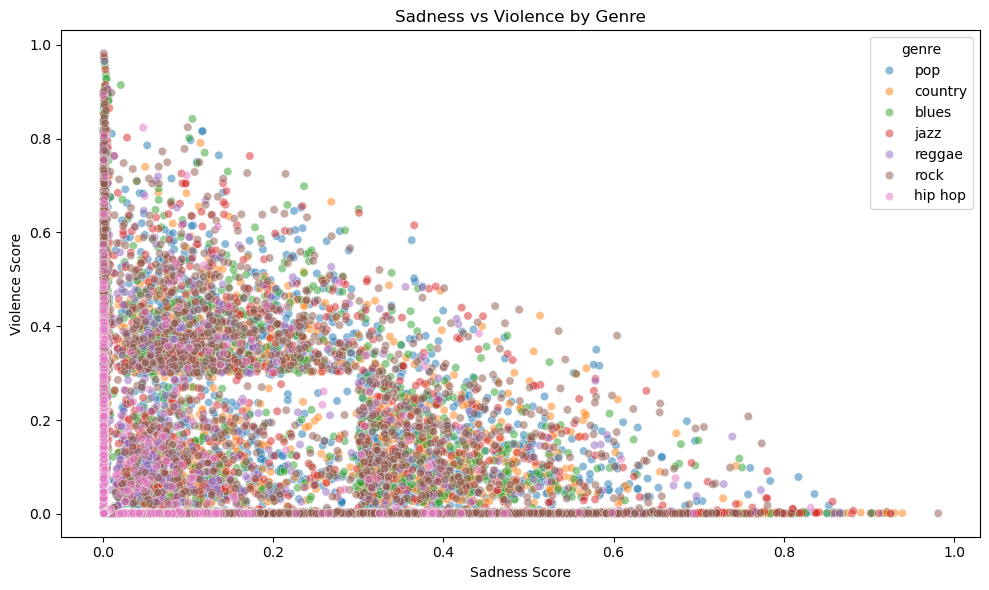

In [30]:
# Setting the figure size for the scatter plot
plt.figure(figsize=(10, 6))

# Creating a scatter plot to compare sadness and violence scores
# Each point represents a song in the dataset
sns.scatterplot(
    data=df,
    x="sadness",
    y="violence",
    hue="genre",        # colors the points by genre to help compare genre patterns
    alpha=0.5           # makes the points semi-transparent so overlapping points are easier to see
)

# Adding a clear title and axis labels
plt.title("Sadness vs Violence by Genre")
plt.xlabel("Sadness Score")
plt.ylabel("Violence Score")

# Adjusting spacing so labels, title, and legend fit properly
plt.tight_layout()

# Saving the plot as an image
plt.savefig("../docs/images/sadness_vs_violence_by_genre.png")

# Displaying the scatter plot
plt.show()

<u>Insights:</u>
* **Most songs have low sadness and low-to-moderate violence scores**, with many points clustered near the lower-left area of the chart.
* **There is a dense vertical cluster at sadness = 0**, meaning many songs have little to no sadness score but still vary widely in violence score.
* **Higher sadness scores are usually associated with lower violence scores**, especially as sadness moves above around 0.6, where violence scores are mostly close to zero.
* **Genres overlap heavily**, meaning sadness and violence alone do not clearly separate most genres in this dataset.
* **A few songs show high violence scores near 0.8–1.0**, but these mostly occur when sadness is very low, suggesting highly violent-themed songs are not usually sad-themed at the same time.

---

### **EDA Hypothesis**

Based on the exploratory data analysis, my hypothesis is that songs can be grouped more effectively by their lyrical topic scores than by genre alone. The dataset shows that themes such as sadness, violence, obscene content, and world/life appear differently across genres, but the genre groups still overlap heavily. This suggests that a recommendation model using topic-based features, lyric length, and possibly age may be able to identify songs with similar emotional or lyrical patterns, even if they belong to different genres.

For the modeling phase, I expect that songs with similar topic score patterns will cluster closer together in an unsupervised learning model. I also expect that features like `release_date` and `age` may need to be handled carefully because they carry almost the same information, while `len` may need scaling because lyric length has a wider range than most topic scores.